In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")
np.random.seed(42)

N = 30000
dimensions = np.arange(1, 51)
fractions = []

for d in dimensions:
    X = np.random.randn(N, d)

    # Define subset by first coordinate
    mask = (X[:, 0] > 1) & (X[:, 0] < 3)
    group = X[mask]

    if len(group) < 10:
        fractions.append(np.nan)
        continue

    # Group centroid
    centroid = group.mean(axis=0)

    # Distances of group points to group centroid
    group_distances = np.linalg.norm(group - centroid, axis=1)

    # 1 standard deviation of group distances
    sigma = group_distances.std()

    # Fraction of group inside 1σ
    frac = np.mean(group_distances <= sigma)
    fractions.append(frac)

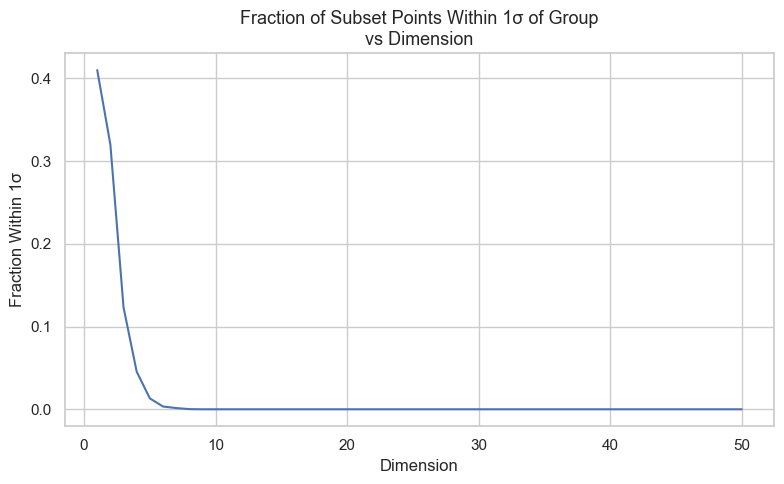

In [3]:
plt.figure(figsize=(8,5))
sns.lineplot(x=dimensions, y=fractions)

plt.title("Fraction of Subset Points Within 1σ of Group\nvs Dimension",
          fontsize=13)
plt.xlabel("Dimension")
plt.ylabel("Fraction Within 1σ")
plt.tight_layout()
plt.show()

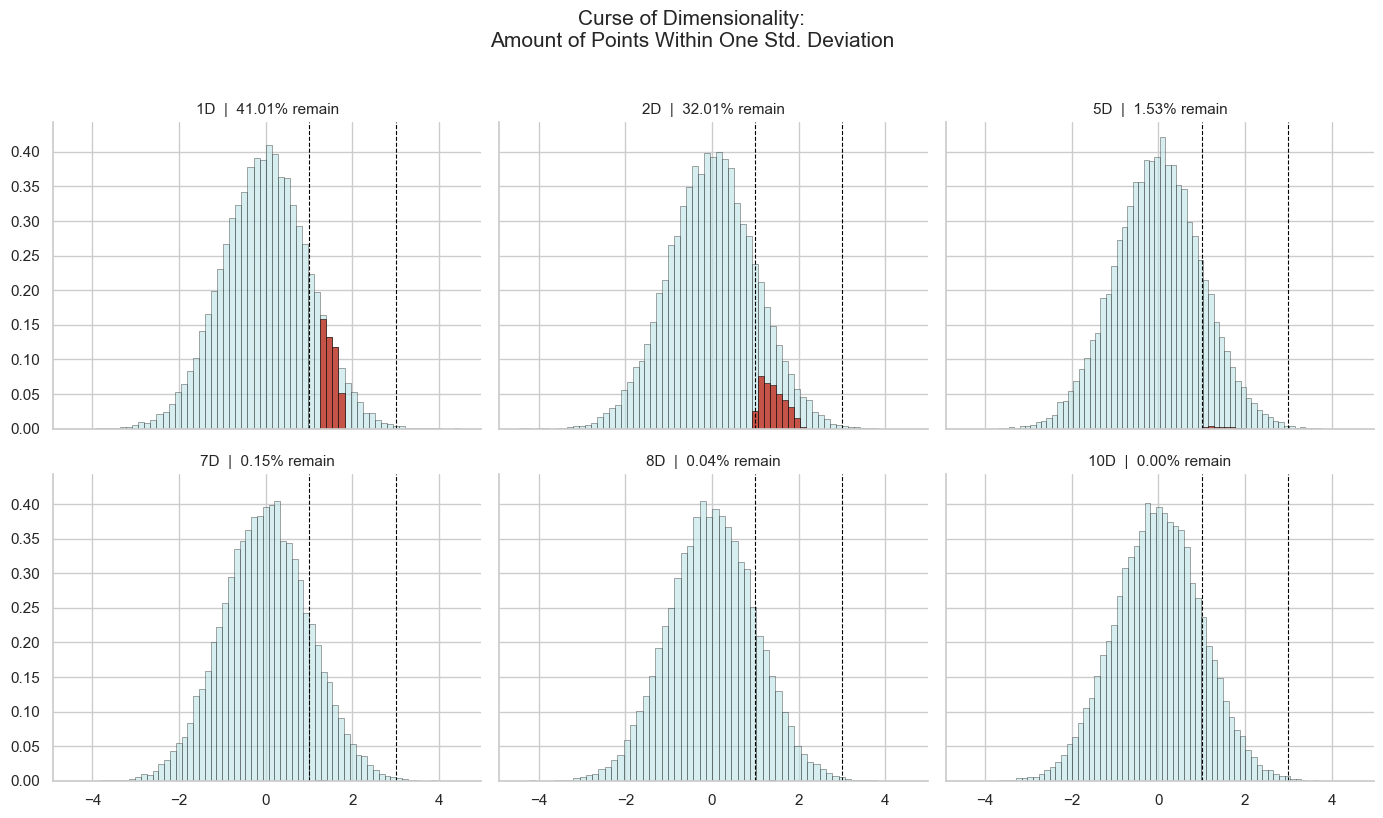

In [ ]:
sns.set_theme(style="whitegrid")
np.random.seed(42)

N = 30000
dims_to_plot = [1, 2, 5, 7, 8, 10]

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, d in zip(axes, dims_to_plot):

    X = np.random.randn(N, d)

    # Subset defined by first coordinate
    mask = (X[:, 0] > 1) & (X[:, 0] < 3)
    group = X[mask]

    if len(group) < 10:
        continue

    centroid = group.mean(axis=0)
    distances = np.linalg.norm(group - centroid, axis=1)
    sigma = distances.std()

    # Surviving points within 1σ
    survivors = group[distances <= sigma]

    fraction_remaining = len(survivors) / len(group)

    # Histogram
    counts, bins = np.histogram(X[:, 0], bins=60, density=True)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_width = bins[1] - bins[0]

    ax.bar(bin_centers, counts,
           width=bin_width,
           color='#bce4e5',
           edgecolor='black',
           linewidth=0.4,
           alpha=0.6)

    # Highlight surviving subset only
    if len(survivors) > 0:
        surv_counts, _ = np.histogram(
        survivors[:, 0],
        bins=bins,
        weights=np.ones(len(survivors)) / (N * bin_width)
    )

        ax.bar(bin_centers, surv_counts,
               width=bin_width,
               color='#c55347',
               edgecolor='black',
               linewidth=0.4)

    ax.axvline(1, color='black', linestyle='--', linewidth=0.8)
    ax.axvline(3, color='black', linestyle='--', linewidth=0.8)

    ax.set_title(f"{d}D  |  {fraction_remaining:.2%} remain",
                 fontsize=11)

sns.despine()
fig.suptitle("Curse of Dimensionality:\nAmount of Points Within One Std. Deviation",
             fontsize=15, y=1.02)

plt.tight_layout()
plt.show()

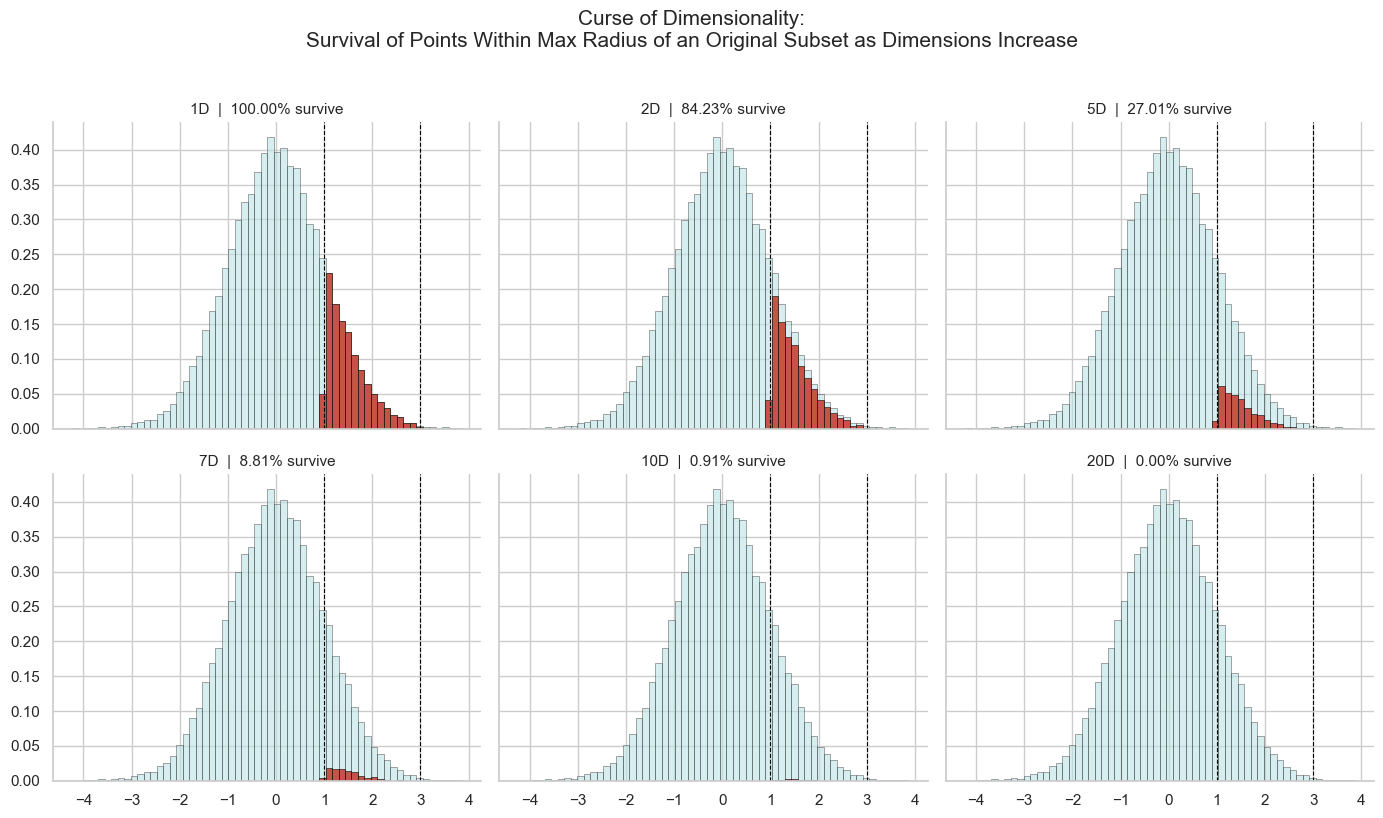

In [ ]:
sns.set_theme(style="whitegrid")
np.random.seed(42)

N = 30000
dims_to_plot = [1, 2, 5, 7, 10, 20]
D_max = max(dims_to_plot)

# Generate a single dataset
X_full = np.random.randn(N, D_max)

# Subset defined ONLY by first coordinate
mask = (X_full[:, 0] > 1) & (X_full[:, 0] < 3)
group_full = X_full[mask]

# Step 2: Compute fixed 1D radius
group_1d = group_full[:, :1]
centroid_1d = group_1d.mean(axis=0)
fixed_radius = np.max(np.abs(group_1d - centroid_1d))

# Step 3: Multi-panel plot (Hopefully still counts as a 'single' figure)
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, d in zip(axes, dims_to_plot):

    X = X_full[:, :d]
    group = group_full[:, :d]

    centroid = group.mean(axis=0)
    distances = np.linalg.norm(group - centroid, axis=1)

    survivors = group[distances <= fixed_radius]
    fraction_remaining = len(survivors) / len(group)

    counts, bins = np.histogram(X[:, 0], bins=60, density=True)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_width = bins[1] - bins[0]

    ax.bar(bin_centers, counts,
           width=bin_width,
           color='#bce4e5',
           edgecolor='black',
           linewidth=0.4,
           alpha=0.6)

    if len(survivors) > 0:
        surv_counts, _ = np.histogram(
            survivors[:, 0],
            bins=bins,
            weights=np.ones(len(survivors)) / (N * bin_width)
        )

        ax.bar(bin_centers, surv_counts,
               width=bin_width,
               color='#c55347',
               edgecolor='black',
               linewidth=0.4)

    ax.axvline(1, color='black', linestyle='--', linewidth=0.8)
    ax.axvline(3, color='black', linestyle='--', linewidth=0.8)

    ax.set_title(f"{d}D  |  {fraction_remaining:.2%} survive",
                 fontsize=11)

sns.despine()
fig.suptitle("Curse of Dimensionality:\nSurvival of Points Within Max Radius of an Original Subset as Dimensions Increase",
             fontsize=15, y=1.02)

plt.tight_layout()
plt.show()